In [1]:
import os
import sys
import argparse
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
from obspy import UTCDateTime, Stream
from tqdm import tqdm
import seaborn as sns
from obspy import read

plt.rcParams.update({
    'font.size': 7,             # Set global font size
    'font.family': 'Arial',      # Set global font family
    'legend.fontsize': 6,        # Set legend font size
    'figure.figsize': (5.5, 3.5), # Set figure size in inches
    'axes.formatter.limits': (-3, 6),
    'axes.formatter.use_mathtext': True,
})
plt.rcParams["mathtext.fontset"] = "cm"
sns.set_context("notebook", font_scale=1)  # Ensures Seaborn uses updated fonts/sizes
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import ttest_ind_from_stats

from collections import Counter
import scipy.stats as stats

import sys
sys.path.append('../../')

from functions.data_processing.read_data import load_seismic_data, load_label, load_seismic_data_test, load_data

plt.rcParams.update( {'font.size':7,
                      'axes.formatter.limits': (-3, 6),
                      'axes.formatter.use_mathtext': True} )
import json
from matplotlib.ticker import ScalarFormatter, MultipleLocator

import obspy
from obspy import read_inventory

In [33]:
import numpy as np
from datetime import datetime
from obspy import read, Trace, Stream, read_inventory, signal, UTCDateTime

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def convert_st2tr(st):

    if isinstance(st, Stream):
        st = st[0]
    elif isinstance(st, Trace):
        pass
    else:
        print(f"!!! Error\n"
              f"Make sure the input for <convert_st2tr> is Obspy 'Trace' or 'Stream'.")

    return st

def rewrite_x_ticks(ax, data_start, data_end, data_sps, x_interval=1):
    '''
    Re write the x/time ticks

    Args:
        ax:
        data_start:
        data_end:
        data_sps:
        x_interval: for PSD, levea it as 1, for waveform or other, set as SPS

    Returns:

    '''
    start = UTCDateTime(data_start).timestamp
    end = UTCDateTime(data_end).timestamp

    x_location = np.arange(start, end + 1, 3600 * x_interval)
    x_ticks = []
    for j, k in enumerate(x_location):
        if j == 0:
            fmt = "%Y-%m-%d\n%H:%M:%S"
        else:
            fmt = "%H:%M"
        x_ticks.append(datetime.utcfromtimestamp(int(k)).strftime(fmt))

    x_location = (x_location - start) * data_sps

    ax.set_xticks(x_location, x_ticks)

def psd_plot(fig, ax, cbar_ax, st, fix_colorbar=True, per_lap=0.5, wlen=60, x_interval=1):

    st = convert_st2tr(st)
    st.spectrogram(per_lap=per_lap, wlen=wlen, log=False, dbscale=True, mult=True, title="", axes=ax, cmap='inferno')
    data_sps = 1 / (per_lap * wlen)

    if fix_colorbar is True:
        ax.images[0].set_clim(-180, -100) # from experiences

    ax.set_ylim(1, 30)
    ax.set_yticks([1, 5, 10, 15, 20, 25, 30], [1, 5, 10, 15, 20, 25, 30])
    ax.tick_params(axis='y', which='major', labelsize=7, length=3)
    ax.tick_params(axis='x', which='major', labelsize=5, length=2)
    ax.set_ylabel('Frequency (Hz)', weight='bold', fontsize=7)

    if cbar_ax is not None:
        cbar = fig.colorbar(ax.images[0], cax=cbar_ax, orientation="vertical")
        cbar.set_label("Power Spectral Density (dB)", fontsize=7)

    rewrite_x_ticks(ax,
                    data_start=st.stats.starttime,
                    data_end=st.stats.endtime,
                    data_sps=1, # fixed for psd
                    x_interval=x_interval)


    return ax, data_sps

def waveform_plot(ax, st, x_interval=1):

    st = convert_st2tr(st)
    data_source = f"{st.stats.network}-{st.stats.station}-{st.stats.channel}-SPS={int(st.stats.sampling_rate)}"

    ax.plot(st.data, color="black", label=data_source)
    ax.set_xlim(0, st.data.size)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(st.stats.sampling_rate * 3600 * x_interval))  # unit is saecond
    ax.legend(loc="upper left", fontsize=6)
    ax.set_ylabel('Ampitude\n[m/s]', weight='bold')

    rewrite_x_ticks(ax,
                    data_start=st.stats.starttime,
                    data_end=st.stats.endtime,
                    data_sps=st.stats.sampling_rate,
                    x_interval=x_interval)

    return ax


In [3]:
st_base = read("../../data/9S.ILL11.EHZ.2019.172.mseed")
# st_base.trim(starttime=UTCDateTime("2019-06-21T18:00:00"), endtime=UTCDateTime("2019-06-21T23:59:59"))
st = st_base.copy()
st.merge(method=1, fill_value='latest', interpolation_samples=0)
st._cleanup()
st.detrend('linear')
st.detrend('demean')
inv = read_inventory("../../meta_data/9S_2017_2023.xml")
st.remove_response(inventory=inv)
st.filter('highpass', freq=1)

c:\Users\kshit\anaconda3\envs\xlstm_env\Lib\site-packages\obspy\core\inventory\inventory.py:451: UserWarning: Found more than one matching response. Returning first.
  warnings.warn(msg)


1 Trace(s) in Stream:
9S.ILL11..HHZ | 2019-06-21T00:00:00.000000Z - 2019-06-22T00:00:00.000000Z | 100.0 Hz, 8640001 samples

In [4]:

st_filtered = st.copy()
st_filtered.filter('bandpass', freqmin=1, freqmax=30)
st_base.trim(starttime=UTCDateTime("2019-06-21T19:30:00"), endtime=UTCDateTime("2019-06-21T22:30:00"))
st.trim(starttime=UTCDateTime("2019-06-21T19:30:00"), endtime=UTCDateTime("2019-06-21T22:30:00"))
st_filtered.trim(starttime=UTCDateTime("2019-06-21T19:30:00"), endtime=UTCDateTime("2019-06-21T22:30:00"))

st_final = st_filtered.copy()
st_final[0].data = st_final[0].data * 1e3
data_envelope = obspy.signal.filter.envelope(st_final[0].data)
data = data_envelope
data = data[1:]

In [5]:
st_filtered2 = st_filtered.copy()
st_filtered2.trim(UTCDateTime("2019-06-21T19:42:00"), UTCDateTime("2019-06-21T20:15:00"))
st_final2 = st_filtered2.copy()
st_final2[0].data = st_final2[0].data * 1e3
data_envelope2 = obspy.signal.filter.envelope(st_final2[0].data)
data2 = data_envelope2
data2 = data2[1:]

In [6]:
len(data)

1080000

In [7]:
import json
with open("../../config/event_id_map.json", "r") as f:
    event_map = json.load(f)

In [27]:
base_dir = {i:f"../../output_final3/task2_5_30_{i}/1_60_320/" for i in [1,2]}
event_ids = ["1", "3", "4", "6", "7", "8", "9"]
juldays = [event_map[i]['julday'] if type(event_map[i]['julday']) is int else event_map[i]['julday'][0] for i in event_ids]

interval = 5
config = 'v4'

for model in ['LSTM', 'xLSTM']:
    for i in [1, 2]:
        best_comb = pd.read_csv(f"{base_dir[i]}/model_evaluation/best_combinations.csv")
        best_comb = best_comb[(best_comb['Interval'] == interval) & (best_comb['Config'] == config) & (best_comb['Model'] == model)]
        
        for julday in juldays:
            best_comb_per = best_comb[best_comb['Test'] == julday]
            if best_comb_per.empty:
                continue
                
            test = best_comb_per['Test'].item()
            val = best_comb_per['Val'].item()
            
            df_filename = f"{base_dir[i]}/output_df/{config}/{interval}/{model}_t{test}_v{val}.csv"
            temp = pd.read_csv(df_filename)
            
            # Prepare the dataframe for merging by renaming the column uniquely
            temp_to_merge = temp[['Timestamps', 'Predicted_Output']].rename(
                columns={'Predicted_Output': f'Predicted_Output_{i}'}
            )
            
            var_name = f"dfcomp_{model}{julday}"
            
            if i == 1:
                globals()[var_name] = temp_to_merge
            else:
                globals()[var_name] = pd.merge(
                    left=globals()[var_name],
                    right=temp_to_merge,
                    on='Timestamps',
                    how='left'
                )

# Calculate Mean and Std across all merged versions
for model in ['LSTM', 'xLSTM']:
    for julday in juldays:
        var_name = f"dfcomp_{model}{julday}"
        if var_name in globals():
            df = globals()[var_name]
            # Select all columns that start with 'Predicted_Output_' to calculate stats
            po_cols = [col for col in df.columns if col.startswith('Predicted_Output_')]
            
            df['Mean_PO'] = df[po_cols].mean(axis=1)
            df['Std_PO'] = df[po_cols].std(axis=1)


In [28]:
minutes = []
p50 = []
p975 = []
julday = 172
starttimes = []
endtimes = []
for model in ['xLSTM', 'LSTM']:
    starttime = globals()[f"dfcomp_{model}{julday}"][globals()[f"dfcomp_{model}{julday}"]["Mean_PO"] > globals()[f"dfcomp_{model}{julday}"]["Mean_PO"].quantile(0.5)]['Timestamps'].iloc[0]
    endtime = globals()[f"dfcomp_{model}{julday}"][globals()[f"dfcomp_{model}{julday}"]["Mean_PO"] > globals()[f"dfcomp_{model}{julday}"]["Mean_PO"].quantile(0.975)]['Timestamps'].iloc[0]
    print(model, julday, starttime, endtime, UTCDateTime(endtime)-UTCDateTime(starttime))
    minutes.append(UTCDateTime(endtime)-UTCDateTime(starttime))
    p50.append(globals()[f"dfcomp_{model}{julday}"]["Mean_PO"].quantile(0.5))
    p975.append(globals()[f"dfcomp_{model}{julday}"]["Mean_PO"].quantile(0.975))
    starttimes.append(starttime)
    endtimes.append(endtime)

xLSTM 172 2019-06-21T19:42:10.000000Z 2019-06-21T19:47:15.000000Z 305.0
LSTM 172 2019-06-21T19:43:05.000000Z 2019-06-21T19:47:25.000000Z 260.0


In [29]:
260 / 60

4.333333333333333

In [30]:
event_id = "3"
julday = 172
interval = 5
config = 'v4'
# load the label
label = load_label(event_id, "ILL11", interval, "1", trim = True, smoothing = None, divide_by = None)
label_s = load_label(event_id, "ILL11", interval, "1", trim = True, smoothing = 60, divide_by = None)

In [31]:
len(data)

1080000

C:\Users\kshit\AppData\Local\Temp\ipykernel_39708\4271676080.py:44: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  x_ticks.append(datetime.utcfromtimestamp(int(k)).strftime(fmt))


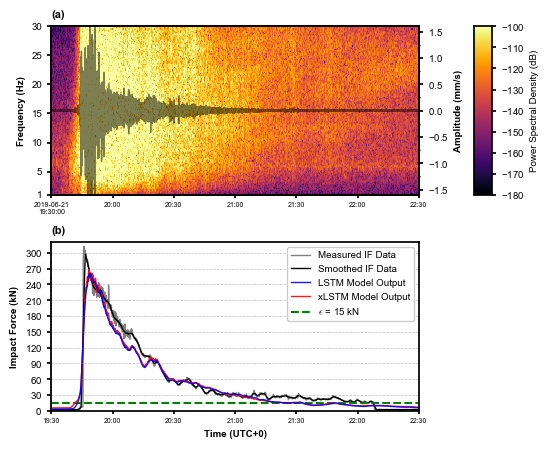

In [34]:
fig, ax = plt.subplots(2, 2, figsize=(5.5, 4.5), width_ratios=[1, 0.05])

psd_plot(fig, ax[0,0], ax[0,1], st_filtered, True, per_lap=0.9, wlen=5, x_interval=0.5)
ax[0,1].tick_params(labelsize=7, length=3)
ax[0,1].yaxis.label.set_fontsize(7)

ax_t = ax[0,0].twinx()
ax_t.plot(np.arange(0, 10800, 0.01), st_filtered[0].data[1:] * 1e3, color="k", alpha=0.5, linewidth=1)
ax_t.set_ylim(-1.6, 1.6)
ax_t.set_ylabel("Amplitude (mm/s)", fontsize=7, weight='bold')
ax_t.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax_t.yaxis.set_major_locator(MultipleLocator(0.5))
ax_t.yaxis.set_minor_locator(MultipleLocator(0.25))
ax_t.tick_params(axis='y', which='major', labelsize=7, length=3)
ax_t.tick_params(axis='x', which='major', labelsize=5, length=2)
ax_t.tick_params(axis='y', which='minor', labelsize=7, length=1)

d2 = ax[1,0].plot(label.Timestamp.apply(lambda x: UTCDateTime(x).matplotlib_date).to_numpy(),
            label['Fv [kN]'], color="black", alpha=0.5, linewidth=1, label="Measured IF Data", zorder=0)
d4 = ax[1,0].plot(label_s.Timestamp.apply(lambda x: UTCDateTime(x).matplotlib_date).to_numpy(),
            label_s['Fv [kN]'], color="black", alpha=1, linewidth=1, label="Smoothed IF Data", zorder=0)
temp = globals()[f"dfcomp_xLSTM{julday}"].copy()

times = temp.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date).to_numpy()
mean = temp.Mean_PO.to_numpy()
std = temp.Std_PO.to_numpy() if 'Std_PO' in temp.columns else np.zeros_like(mean)

d3 = ax[1,0].plot(times, mean, color='red', alpha=0.9, linewidth=1, label='xLSTM Model Output', zorder=1)
# ax[1,0].fill_between(times,
#                     mean - std,
#                     mean + std,
#                     color='green',
#                     alpha=0.5,
#                     linewidth=0,
#                     label="Std. Model Output",
#                     zorder=0)

temp = globals()[f"dfcomp_LSTM{julday}"].copy()
times = temp.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date).to_numpy()
mean = temp.Mean_PO.to_numpy()
std = temp.Std_PO.to_numpy() if 'Std_PO' in temp.columns else np.zeros_like(mean)

d5 = ax[1,0].plot(times, mean, color='blue', alpha=0.9, linewidth=1, label='LSTM Model Output', zorder=1)
# ax[1,0].fill_between(times,
#                     mean - std,
#                     mean + std,
#                     color='turquoise',
#                     alpha=0.3,
#                     linewidth=0,
#                     label="Std. Model Output",
#                     zorder=0)
ax[1,0].set_ylim(0, 320);
ax[1,0].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax[1,0].yaxis.set_major_locator(MultipleLocator(30))
ax[1,0].yaxis.set_minor_locator(MultipleLocator(5))
ax[1,0].tick_params(axis='y', which='major', labelsize=7, length=3)
ax[1,0].tick_params(axis='x', which='major', labelsize=5, length=2)
ax[1,0].tick_params(axis='y', which='minor', labelsize=7, length=1)
ax[1,0].set_xlabel("Time (UTC+0)", fontweight='bold', fontsize=7)
ax[1,0].set_ylabel("Impact Force (kN)", fontweight='bold', fontsize=7)
d6 = ax[1,0].axhline([15], color="green", linestyle="--", label=r"$\epsilon$ = 15 kN", zorder=0)
lns = d2+d4+d5+d3+[d6]
labs = [l.get_label() for l in lns]
leg = ax[1,0].legend(lns, labs, loc='upper right', fontsize=7)
if leg:
    leg.get_frame().set_alpha(1)
ax[1,0].grid(axis='y', color='grey', linestyle='--', lw=0.5, alpha=0.5, zorder=0)

ax[1,0].xaxis_date()
ax[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax[1,0].set_xlim(UTCDateTime("2019-06-21T19:30:00").matplotlib_date, UTCDateTime("2019-06-21T22:30:00").matplotlib_date)
fig.delaxes(ax[1,1])
# fig.delaxes(ax[0,1])
# ax[0,0].text(0.9, 0.9, '(a)', transform=ax[0,0].transAxes, fontsize=12, va='top', ha='right')
ax[0,0].set_title(label="(a)", loc="left", fontsize=8, fontweight="bold")
ax[1,0].set_title(label="(b)", loc="left", fontsize=8, fontweight="bold") 
fig.tight_layout()
fig.savefig("1-Figure-5.png", dpi=600, transparent=False)
# plt.close(fig=fig)

In [44]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

/var/folders/9b/f10dy2654w79wqw49pdgt37c0000gp/T/ipykernel_85250/4223589958.py:44: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  x_ticks.append(datetime.utcfromtimestamp(int(k)).strftime(fmt))


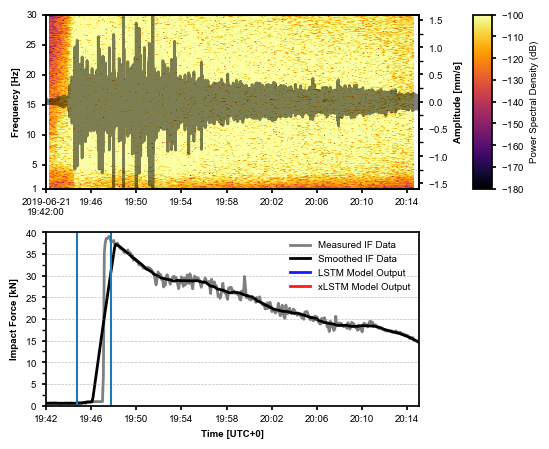

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(5.5, 4.5), width_ratios=[1, 0.05])

psd_plot(fig, ax[0,0], ax[0,1], st_filtered2, True, per_lap=0.9, wlen=60, x_interval=4/60)
ax[0,1].tick_params(labelsize=7, length=3)
ax[0,1].yaxis.label.set_fontsize(7)
# ax[0].set_xlabel("Time [UTC+0]", fontsize=12, weight='bold')
# ax[0].set_xlim(60, 1920)

ax_t = ax[0,0].twinx()
ax_t.plot(np.arange(0, 1980, 0.01), st_filtered2[0].data[1:] * 1e3, color="k", alpha=0.5, linewidth=2)
ax_t.set_ylim(-1.6, 1.6)
ax_t.set_ylabel("Amplitude [mm/s]", fontsize=7, weight='bold')
ax_t.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax_t.yaxis.set_major_locator(MultipleLocator(0.5))
ax_t.yaxis.set_minor_locator(MultipleLocator(0.25))
ax_t.tick_params(axis='both', which='major', labelsize=7, length=3)
ax_t.tick_params(axis='y', which='minor', labelsize=7, length=3)

d2 = ax[1,0].plot(label.Timestamp.apply(lambda x: UTCDateTime(x).matplotlib_date).to_numpy(),
            label['Fv [kN]'], color="black", alpha=0.5, linewidth=2, label="Measured IF Data", zorder=0)
d4 = ax[1,0].plot(label_s.Timestamp.apply(lambda x: UTCDateTime(x).matplotlib_date).to_numpy(),
            label_s['Fv [kN]'], color="black", alpha=1, linewidth=2, label="Smoothed IF Data", zorder=0)
temp = globals()[f"dfcomp_xLSTM{julday}"].copy()

times = temp.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date).to_numpy()
mean = temp.Mean_PO.to_numpy()
std = temp.Std_PO.to_numpy() if 'Std_PO' in temp.columns else np.zeros_like(mean)

d3 = ax[1,0].plot(times, mean, color='red', alpha=0.9, linewidth=2, label='xLSTM Model Output', zorder=1)
ax[1,0].fill_between(times,
                    mean - std,
                    mean + std,
                    color='green',
                    alpha=0.5,
                    linewidth=0,
                    label="Std. Model Output",
                    zorder=0)

temp = globals()[f"dfcomp_LSTM{julday}"].copy()
times = temp.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date).to_numpy()
mean = temp.Mean_PO.to_numpy()
std = temp.Std_PO.to_numpy() if 'Std_PO' in temp.columns else np.zeros_like(mean)

d5 = ax[1,0].plot(times, mean, color='blue', alpha=0.9, linewidth=2, label='LSTM Model Output', zorder=1)
ax[1,0].fill_between(times,
                    mean - std,
                    mean + std,
                    color='turquoise',
                    alpha=0.3,
                    linewidth=0,
                    label="Std. Model Output",
                    zorder=0)
ax[1,0].set_ylim(-0.2, 40);
ax[1,0].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax[1,0].yaxis.set_major_locator(MultipleLocator(5))
ax[1,0].yaxis.set_minor_locator(MultipleLocator(2.5))
ax[1,0].tick_params(axis='both', which='major', labelsize=7, length=3)
ax[1,0].tick_params(axis='y', which='minor', labelsize=7, length=3)
ax[1,0].set_xlabel(f"Time [UTC+0]", fontweight='bold', fontsize=7)
ax[1,0].set_ylabel("Impact Force [kN]", fontweight='bold', fontsize=7)
lns = d2+d4+d5+d3
labs = [l.get_label() for l in lns]
leg = ax[1,0].legend(lns, labs, loc='upper right', fontsize=7)
if leg:
    leg.get_frame().set_alpha(0)
ax[1,0].grid(axis='y', color='grey', linestyle='--', lw=0.5, alpha=0.5, zorder=0)
ax[1,0].xaxis_date()
ax[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# ax[1,0].xaxis.set_major_locator(mdates.MinuteLocator(interval=4))
start = UTCDateTime("2019-06-21T19:42:00").matplotlib_date
end = UTCDateTime("2019-06-21T20:15:00").matplotlib_date
ax[1,0].set_xticks(np.arange(start, end + 1e-9, 4 / (24 * 60)))  # 10-minute ticks starting at start
ax[1,0].set_xlim(UTCDateTime("2019-06-21T19:42:00").matplotlib_date, UTCDateTime("2019-06-21T20:15:00").matplotlib_date)
# a, b = UTCDateTime("2019-06-21T19:44:45.000000Z").matplotlib_date, UTCDateTime("2019-06-21T19:47:45.000000Z").matplotlib_date
# ax[1,0].vlines([a, b], ymin=0, ymax=40)
# ax.vlines(x=[starttimes], ymin=-1, ymax=45)
# ax.vlines(x=[endtimes], ymin=-1, ymax=45)
# ax[0,0].set_title("(b)", loc="left", fontsize=7) 
fig.delaxes(ax[1,1])
fig.tight_layout()
# fig.savefig(f"./output_images11/172-Impact-Force-zoom.png", dpi=600, transparent=False)
# plt.close(fig=fig)

In [238]:
fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.5))

d2 = ax.plot(label.Timestamp.apply(lambda x: UTCDateTime(x).matplotlib_date).to_numpy(),
            label['Fv [kN]'], color="black", alpha=0.5, linewidth=2, label="Measured IF Data", zorder=0)
d4 = ax.plot(label_s.Timestamp.apply(lambda x: UTCDateTime(x).matplotlib_date).to_numpy(),
            label_s['Fv [kN]'], color="black", alpha=1, linewidth=2, label="Smoothed IF Data", zorder=0)
temp = globals()[f"dfcomp_xLSTM{julday}"].copy()

times = temp.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date).to_numpy()
mean = temp.Mean_PO.to_numpy()
std = temp.Std_PO.to_numpy() if 'Std_PO' in temp.columns else np.zeros_like(mean)

d3 = ax.plot(times, mean, color='red', alpha=0.9, linewidth=2, label='xLSTM Model Output', zorder=1)
ax.fill_between(times,
                    mean - std,
                    mean + std,
                    color='red',
                    alpha=0.5,
                    linewidth=0,
                    label="Std. Model Output",
                    zorder=0)

temp = globals()[f"dfcomp_LSTM{julday}"].copy()
times = temp.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date).to_numpy()
mean = temp.Mean_PO.to_numpy()
std = temp.Std_PO.to_numpy() if 'Std_PO' in temp.columns else np.zeros_like(mean)

d5 = ax.plot(times, mean, color='blue', alpha=0.9, linewidth=2, label='LSTM Model Output', zorder=1)
ax.fill_between(times,
                    mean - std,
                    mean + std,
                    color='blue',
                    alpha=0.3,
                    linewidth=0,
                    label="Std. Model Output",
                    zorder=0)
ax.set_ylim(-0.2, 40);
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(2.5))
ax.tick_params(axis='y', which='major', labelsize=12, length=3)
ax.tick_params(axis='y', which='minor', labelsize=12, length=3)
ax.set_xlabel(f"Time [UTC+0]", fontweight='bold', fontsize=12)
ax.set_ylabel("Impact Force [kN]", fontweight='bold', fontsize=12)
lns = d2+d4+d5+d3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='upper right')
ax.grid(axis='y', color='grey', linestyle='--', lw=0.5, alpha=0.5, zorder=0)
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
ax.set_xlim(UTCDateTime("2019-06-21T20:42:00").matplotlib_date, UTCDateTime("2019-06-21T22:30:00").matplotlib_date)
ax.vlines(x=[starttimes], ymin=-1, ymax=45)
ax.vlines(x=[endtimes], ymin=-1, ymax=45)
fig.tight_layout()

fig.savefig(f"./output_images9/172-Impact-Force-zoom-transition.png", dpi=600)
plt.close(fig=fig)

# Velocity Temporal Relation Plot

In [3]:
thr = 2.0

In [4]:
import json
with open("../config/event_id_map.json", "r") as f:
    event_map = json.load(f)

In [99]:
any(diffs[0:5] > 0.05)

False

In [123]:
def get_starttime_endtime(df1):
    try:
        col = df1["Predicted_Output_Mean"]
    except KeyError:
        col = df1['Mean_PO']
    diffs = col.diff()  # diffs[i] = col[i] - col[i-1]
    # starttime = df1[col > thr]['Timestamps'].iloc[0]
    starttimes = []
    endtimes = []

    for i in range(5, len(df1) - 2):
        if (col.iloc[i] > 2) and (all(diffs.iloc[i:i+2] > 0)) and (any(diffs.iloc[i:i+5] > 0.05)):
            starttimes.append(df1["Timestamps"].iloc[i])
        if (diffs.iloc[i] < -0.1) and (all(diffs.iloc[i:i+3] < 0)) and (any(diffs.iloc[i-5:i] > 0.05)):
            endtimes.append(df1["Timestamps"].iloc[i])
            # break  # keep the break if you only want the first occurrence anyway

    if not endtimes:
        for i in range(len(df1)):
            if (diffs.iloc[i] < -0.1) and (all(diffs.iloc[i:i+2] < 0)):
                endtimes.append(df1["Timestamps"].iloc[i])
    # display(len(starttimes))
    # display(len(endtimes))
    if starttimes:
        starttime = starttimes[0]
    else:
        starttime = df1["Timestamps"].iloc[0]
    if endtimes:
        endtime = endtimes[0]
    else:
        endtime = df1["Timestamps"].iloc[-1]
    # endtime = df1["Timestamps"].iloc[diffs[diffs == diffs.min()].index].item()
    return starttime, endtime

In [124]:
base_dir = {i:f"../comparison2_v2/comparison_baseline_cv2_5_30_{i}/1_60_45/" for i in [1,2,3]}
display(base_dir)
event_ids = ["1", "3", "4", "6", "7", "8", "9"]
juldays = [event_map[i]['julday'] if type(event_map[i]['julday']) is int else event_map[i]['julday'][0] for i in event_ids]
# globals()[f'dfcomp_{julday}']
interval = 5
config = 'v4'
year = 2019
for model in ['LSTM', 'xLSTM']:
    for i in [1,2,3]:
        best_comb = pd.read_csv(f"{base_dir[i]}/model_evaluation/best_combinations.csv")
        best_comb = best_comb[(best_comb['Interval'] == interval) & (best_comb['Config'] == config) & (best_comb['Model'] == model)]
        for julday in (juldays):
            best_comb_per = best_comb[best_comb['Test'] == julday]
            test = best_comb_per['Test'].item()
            val = best_comb_per['Val'].item()
            # print(test, val)
            df_filename = f"{base_dir[i]}/output_df/{config}/{interval}/{model}_t{test}_v{val}.csv"
            temp = pd.read_csv(df_filename)
            if i == 1:
                globals()[f"dfcomp_{model}{julday}"] = temp
            else:
                globals()[f"dfcomp_{model}{julday}"] = pd.merge(left=globals()[f"dfcomp_{model}{julday}"],
                                                        right=temp[['Timestamps','Predicted_Output']],
                                                        on='Timestamps',
                                                        how='left',
                                                        )
for model in ['LSTM', 'xLSTM']:
    for julday in juldays:
        globals()[f"dfcomp_{model}{julday}"]['Mean_PO'] = globals()[f"dfcomp_{model}{julday}"][['Predicted_Output_x', 'Predicted_Output_y', 'Predicted_Output']].mean(axis=1)
        globals()[f"dfcomp_{model}{julday}"]['Std_PO'] = globals()[f"dfcomp_{model}{julday}"][['Predicted_Output_x', 'Predicted_Output_y', 'Predicted_Output']].std(axis=1)

minutes = []
p50 = []
p975 = []
for model in ['xLSTM']:
    for julday in juldays:
        # if julday != 183:
        # starttime = globals()[f"dfcomp_{model}{julday}"][globals()[f"dfcomp_{model}{julday}"]["Mean_PO"] > globals()[f"dfcomp_{model}{julday}"]["Mean_PO"].quantile(0.5)]['Timestamps'].iloc[0]
        # starttime = globals()[f"dfcomp_{model}{julday}"][globals()[f"dfcomp_{model}{julday}"]["Mean_PO"] > thr]['Timestamps'].iloc[0]
        # endtime = globals()[f"dfcomp_{model}{julday}"][globals()[f"dfcomp_{model}{julday}"]["Mean_PO"] > globals()[f"dfcomp_{model}{julday}"]["Mean_PO"].quantile(0.95)]['Timestamps'].iloc[0]
        df = globals()[f"dfcomp_{model}{julday}"].copy()
        starttime, endtime = get_starttime_endtime(df)
        print(model, julday, starttime, endtime, UTCDateTime(endtime)-UTCDateTime(starttime))
        minutes.append(UTCDateTime(endtime)-UTCDateTime(starttime))
        p50.append(globals()[f"dfcomp_{model}{julday}"]["Mean_PO"].quantile(0.5))
        p975.append(globals()[f"dfcomp_{model}{julday}"]["Mean_PO"].quantile(0.95))
        col = df["Mean_PO"]
        diffs = col.diff()  # diffs[i] = col[i] - col[i-1]

        fig, ax = plt.subplots()
        ax.plot(df.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date), df.Mean_PO)
        ax.xaxis_date()
        ax.axvline(UTCDateTime(starttime).matplotlib_date)
        ax.axvline(UTCDateTime(endtime).matplotlib_date)

        axt = ax.twinx()
        axt.plot(df.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date), diffs, "r.", alpha=0.2)
        axt.grid()
        os.makedirs(f"./output_images29/{year}/", exist_ok = True)
        fig.savefig(f"./output_images29/{year}/{julday}.png", dpi=300)
        plt.close(fig=fig)

{1: '../comparison2_v2/comparison_baseline_cv2_5_30_1/1_60_45/',
 2: '../comparison2_v2/comparison_baseline_cv2_5_30_2/1_60_45/',
 3: '../comparison2_v2/comparison_baseline_cv2_5_30_3/1_60_45/'}

xLSTM 161 2019-06-10T18:15:05.000000Z 2019-06-10T18:40:00.000000Z 1495.0
xLSTM 172 2019-06-21T19:42:00.000000Z 2019-06-21T19:48:35.000000Z 395.0
xLSTM 182 2019-07-01T23:27:55.000000Z 2019-07-01T23:33:55.000000Z 360.0
xLSTM 196 2019-07-15T04:13:00.000000Z 2019-07-15T04:25:20.000000Z 740.0
xLSTM 207 2019-07-26T17:46:45.000000Z 2019-07-26T17:55:35.000000Z 530.0
xLSTM 223 2019-08-11T17:09:15.000000Z 2019-08-11T17:14:00.000000Z 285.0
xLSTM 232 2019-08-20T17:01:25.000000Z 2019-08-20T17:12:30.000000Z 665.0


In [134]:
base_dir = "../comparison2_v2/model_test/ILL11"
minutes_20 = []
p50_20, p975_20 = [], []
years = [2020] * 7
juldays = [156, 159, 160, 169, 181, 229, 243]
start_times = ["2020-06-04T15:00:00", "2020-06-07T08:00:00",\
    "2020-06-08T17:00:00",
    "2020-06-17T04:00:00",
    "2020-06-29T05:00:00",
    "2020-08-16T22:00:00",
    "2020-08-30T08:00:00"]
end_times = ["2020-06-04T16:00:00", "2020-06-07T11:00:00",\
    "2020-06-08T20:00:00",
    "2020-06-17T07:00:00",
    "2020-06-29T07:30:00",
    "2020-08-16T23:59:59",
    "2020-08-30T12:00:00"]
station = "ILL11"

# fig, ax = plt.subplots(7, 1, sharey = True, figsize=(7.5,11.5))
for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    if julday in [156, 160, 169, 181, 243]:
        df1 = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday}.csv")
        df1 = df1[df1.Timestamps.between(start_time, end_time)]
        df1.reset_index(inplace=True, drop=True)
        # starttime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.5)]['Timestamps'].iloc[0]
        # starttime = df1[df1["Predicted_Output_Mean"] > thr]['Timestamps'].iloc[0]
        # endtime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.95)]['Timestamps'].iloc[0]
        starttime, endtime = get_starttime_endtime(df1)
        print(model, julday, starttime, endtime, UTCDateTime(endtime)-UTCDateTime(starttime))
        minutes_20.append(UTCDateTime(endtime)-UTCDateTime(starttime))
        p50_20.append(df1["Predicted_Output_Mean"].quantile(0.5))
        p975_20.append(df1["Predicted_Output_Mean"].quantile(0.95))
        col = df1["Predicted_Output_Mean"]
        diffs = col.diff()  # diffs[i] = col[i] - col[i-1]
        fig, ax = plt.subplots()
        ax.plot(df1.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date), df1.Predicted_Output_Mean)
        ax.xaxis_date()
        ax.axvline(UTCDateTime(starttime).matplotlib_date)
        ax.axvline(UTCDateTime(endtime).matplotlib_date)

        axt = ax.twinx()
        axt.plot(df1.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date), diffs, "r.", alpha=0.2)
        axt.grid()
        os.makedirs(f"./output_images29/{year}/", exist_ok = True)
        fig.savefig(f"./output_images29/{year}/{julday}.png", dpi=300)
        plt.close(fig=fig)
        # if julday == 181:
        #     break
        # break

minutes_21 = []
p50_21, p975_21 = [], []
years = [2021] * 11
juldays = [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]
start_times = ["2021-05-11 13:30:00", "2021-05-16 15:30:00", "2021-05-21 22:30:00", "2021-06-05 09:00:00",
            "2021-06-22 19:30:00", "2021-06-24 14:30:00", "2021-07-06 18:30:00", "2021-07-13 15:00:00",
            "2021-07-16 03:00:00", "2021-08-07 14:00:00", "2021-09-19 05:30:00"]
start_times = [UTCDateTime(x) for x in start_times]
end_times = ["2021-05-11 17:00:00", "2021-05-16 20:00:00", "2021-05-22 02:00:00", "2021-06-05 13:00:00",
            "2021-06-22 22:30:00", "2021-06-24 17:30:00", "2021-07-06 21:00:00", "2021-07-13 20:00:00",
            "2021-07-16 08:00:00", "2021-08-07 17:30:00", "2021-09-19 12:30:00"]
end_times = [UTCDateTime(x) for x in end_times]

for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    if julday in [131, 136, 142, 173, 175, 187, 194, 197, 219, 262]:
        if julday == 142:
            dfa = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday-1}.csv", index_col=False)
            dfb = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday}.csv", index_col=False)
            df1 = pd.concat([dfa, dfb], ignore_index=True)
        else:
            df1 = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday}.csv")
        df1 = df1[df1.Timestamps.between(start_time, end_time)]
        df1.reset_index(inplace=True, drop=True)
        # starttime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.5)]['Timestamps'].iloc[0]
        # starttime = df1[df1["Predicted_Output_Mean"] > thr]['Timestamps'].iloc[0]
        # endtime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.95)]['Timestamps'].iloc[0]
        starttime, endtime = get_starttime_endtime(df1)
        print(model, julday, starttime, endtime, UTCDateTime(endtime)-UTCDateTime(starttime))
        minutes_21.append(UTCDateTime(endtime)-UTCDateTime(starttime))
        p50_21.append(df1["Predicted_Output_Mean"].quantile(0.5))
        p975_21.append(df1["Predicted_Output_Mean"].quantile(0.95))
        col = df1["Predicted_Output_Mean"]
        diffs = col.diff()  # diffs[i] = col[i] - col[i-1]
        fig, ax = plt.subplots()
        ax.plot(df1.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date), df1.Predicted_Output_Mean)
        ax.xaxis_date()
        ax.axvline(UTCDateTime(starttime).matplotlib_date)
        ax.axvline(UTCDateTime(endtime).matplotlib_date)

        axt = ax.twinx()
        axt.plot(df1.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date), diffs, "r.", alpha=0.2)
        axt.grid()
        os.makedirs(f"./output_images29/{year}/", exist_ok = True)
        fig.savefig(f"./output_images29/{year}/{julday}.png", dpi=300)
        plt.close(fig=fig)
        # if julday == 219:
        #     break
        # break
        
minutes_22 = []
p50_22, p975_22 = [], []
years = [2022] * 2
juldays = [156, 185]
start_times = ["2022-06-05 10:30:00", "2022-07-04 21:00:00"]
start_times = [UTCDateTime(x) for x in start_times]
end_times = ["2022-06-05 13:30:00", "2022-07-04 23:59:59"]
end_times = [UTCDateTime(x) for x in end_times]

# fig, ax = plt.subplots(2, 1, sharey = True, figsize=(7.5,3.5))
for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    df1 = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday}.csv")
    df1 = df1[df1.Timestamps.between(start_time, end_time)]
    df1.reset_index(inplace=True, drop=True)
    # starttime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.5)]['Timestamps'].iloc[0]
    # starttime = df1[df1["Predicted_Output_Mean"] > thr]['Timestamps'].iloc[0]
    # endtime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.95)]['Timestamps'].iloc[0]
    starttime, endtime = get_starttime_endtime(df1)
    print(model, julday, starttime, endtime, UTCDateTime(endtime)-UTCDateTime(starttime))
    minutes_22.append(UTCDateTime(endtime)-UTCDateTime(starttime))
    p50_22.append(df1["Predicted_Output_Mean"].quantile(0.5))
    p975_22.append(df1["Predicted_Output_Mean"].quantile(0.95))
    col = df1["Predicted_Output_Mean"]
    diffs = col.diff()  # diffs[i] = col[i] - col[i-1]
    fig, ax = plt.subplots()
    ax.plot(df1.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date), df1.Predicted_Output_Mean)
    ax.xaxis_date()
    ax.axvline(UTCDateTime(starttime).matplotlib_date)
    ax.axvline(UTCDateTime(endtime).matplotlib_date)

    axt = ax.twinx()
    axt.plot(df1.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date), diffs, "r.", alpha=0.2)
    axt.grid()
    os.makedirs(f"./output_images29/{year}/", exist_ok = True)
    fig.savefig(f"./output_images29/{year}/{julday}.png", dpi=300)
    plt.close(fig=fig)

minutes_23 = []
p50_23, p975_23 = [], []
years = [2023] * 3
juldays = [153, 161, 193]
start_times = ["2023-06-02 17:00:00", "2023-06-10 05:00:00", "2023-07-12 03:00:00"]
start_times = [UTCDateTime(x) for x in start_times]
end_times = ["2023-06-02 21:00:00", "2023-06-10 09:00:00", "2023-07-12 06:00:00"]
end_times = [UTCDateTime(x) for x in end_times]

for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    df1 = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday}.csv")
    df1 = df1[df1.Timestamps.between(start_time, end_time)]
    df1.reset_index(inplace=True, drop=True)
    # starttime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.5)]['Timestamps'].iloc[0]
    # starttime = df1[df1["Predicted_Output_Mean"] > thr]['Timestamps'].iloc[0]
    # endtime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.95)]['Timestamps'].iloc[0]
    starttime, endtime = get_starttime_endtime(df1)
    print(model, julday, starttime, endtime, UTCDateTime(endtime)-UTCDateTime(starttime))
    minutes_23.append(UTCDateTime(endtime)-UTCDateTime(starttime))
    p50_23.append(df1["Predicted_Output_Mean"].quantile(0.5))
    p975_23.append(df1["Predicted_Output_Mean"].quantile(0.95))
    col = df1["Predicted_Output_Mean"]
    diffs = col.diff()  # diffs[i] = col[i] - col[i-1]
    fig, ax = plt.subplots()
    ax.plot(df1.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date), df1.Predicted_Output_Mean)
    ax.xaxis_date()
    ax.axvline(UTCDateTime(starttime).matplotlib_date)
    ax.axvline(UTCDateTime(endtime).matplotlib_date)

    axt = ax.twinx()
    axt.plot(df1.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date), diffs, "r.", alpha=0.2)
    axt.grid()
    os.makedirs(f"./output_images29/{year}/", exist_ok = True)
    fig.savefig(f"./output_images29/{year}/{julday}.png", dpi=300)
    plt.close(fig=fig)
    # break

xLSTM 156 2020-06-04T15:37:30.000000Z 2020-06-04T15:44:15.000000Z 405.0
xLSTM 160 2020-06-08T17:47:10.000000Z 2020-06-08T18:02:50.000000Z 940.0
xLSTM 169 2020-06-17T04:55:25.000000Z 2020-06-17T05:09:00.000000Z 815.0
xLSTM 181 2020-06-29T05:18:45.000000Z 2020-06-29T05:50:25.000000Z 1900.0
xLSTM 243 2020-08-30T08:03:20.000000Z 2020-08-30T08:11:55.000000Z 515.0
xLSTM 131 2021-05-11T14:37:20.000000Z 2021-05-11T14:51:35.000000Z 855.0
xLSTM 136 2021-05-16T17:05:45.000000Z 2021-05-16T17:15:55.000000Z 610.0
xLSTM 142 2021-05-21T23:22:50.000000Z 2021-05-21T23:33:25.000000Z 635.0
xLSTM 173 2021-06-22T20:23:05.000000Z 2021-06-22T20:29:15.000000Z 370.0
xLSTM 175 2021-06-24T15:26:30.000000Z 2021-06-24T15:31:55.000000Z 325.0
xLSTM 187 2021-07-06T18:59:35.000000Z 2021-07-06T19:06:25.000000Z 410.0
xLSTM 194 2021-07-13T16:40:55.000000Z 2021-07-13T17:11:55.000000Z 1860.0
xLSTM 197 2021-07-16T04:01:00.000000Z 2021-07-16T04:09:25.000000Z 505.0
xLSTM 219 2021-08-07T14:35:25.000000Z 2021-08-07T14:44:45.0000

In [68]:
volume_df = pd.read_csv("../label/DF_Characteristics_2019-2023.csv", index_col=0)
volume_df.drop(1, inplace=True)
volume_df.reset_index(drop=True, inplace=True)
volume_df['Event_Date'] = volume_df['Event_Date'].apply(lambda x: UTCDateTime(x))
volume_df.dropna(axis=0, subset=['Volume'], inplace=True)
# volume_df.tail()
volume_df_2019 = volume_df[(volume_df['Year'] == 2019) & (volume_df['Julday'] != 184)]
volume_df_2019['Event_ID'] = [1, 3, 4, 6, 7, 8, 9]
volume_2019 = volume_df_2019['Volume'].to_list()
vel_2019 = volume_df_2019['Velocity'].to_list()

volume_df_2020 = volume_df[volume_df['Year'] == 2020]
volume_2020 = []
vel_2020 = []
for idx, row in volume_df_2020.iterrows():
    if row['Julday'] in [156, 160, 169, 181, 243]:
        volume_2020.append(row['Volume'])
        vel_2020.append(row['Velocity'])

volume_df_2021 = volume_df[volume_df['Year'] == 2021]
volume_2021 = []
vel_2021 = []
for idx, row in volume_df_2021.iterrows():
    if row['Julday'] in [131, 136, 142, 173, 175, 187, 194, 197, 219, 262]:
        volume_2021.append(row['Volume'])
        vel_2021.append(row['Velocity'])

volume_df_2022 = volume_df[volume_df['Year'] == 2022]
volume_2022 = []
vel_2022 = []
for idx, row in volume_df_2022.iterrows():
    if row['Julday'] in [156, 185]:
        volume_2022.append(row['Volume'])
        vel_2022.append(row['Velocity'])

volume_df_2023 = volume_df[volume_df['Year'] == 2023]
volume_2023 = []
vel_2023 = []
for idx, row in volume_df_2023.iterrows():
    if row['Julday'] in [153, 161, 193]:
        volume_2023.append(row['Volume'])
        vel_2023.append(row['Velocity'])

/var/folders/9b/f10dy2654w79wqw49pdgt37c0000gp/T/ipykernel_57970/2867445633.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volume_df_2019['Event_ID'] = [1, 3, 4, 6, 7, 8, 9]


In [193]:
mins = []
for l in [minutes, minutes_20, minutes_21, minutes_22, minutes_23]:
    mins.extend(l)
vels = []
for v in [vel_2019, vel_2020, vel_2021, vel_2022, vel_2023]:
    vels.extend(v)
# mins = minutes.extend(minutes_20)#, minutes_22, minutes_23)

In [194]:
mins = np.array(mins)
vels = np.array(vels)

In [139]:
vels = vels[mins<1000]
mins = mins[mins<1000]
mins = mins[vels < 10]
vels = vels[vels < 10]

Mins vs Vels (power-law): A=3040.9157, alpha=1.0865
Mins vs Vels (linear): m=-0.0057, b=6.9297


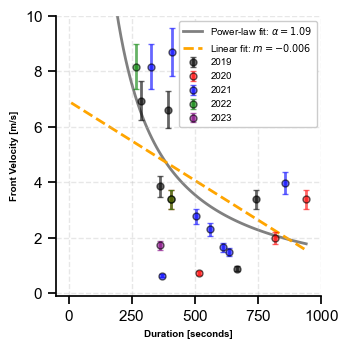

In [146]:
from scipy import optimize as opt

def pl(x, A, alpha):
    """Power-law function: A * x^(-alpha)"""
    return A * np.power(x, -alpha)

def linear(x, m, b):
    """Linear function: m * x + b"""
    return m * x + b

# Fit power-law to mins vs vels
try:
    popt_mins, pcov_mins = opt.curve_fit(pl, mins, vels, p0=[1, 0.5],
                                          bounds=([0, 0.1], [np.inf, 3.0]),
                                          maxfev=5000)
    A_mins, alpha_mins = popt_mins
    print(f"Mins vs Vels (power-law): A={A_mins:.4f}, alpha={alpha_mins:.4f}")
except Exception as e:
    print(f"Failed to fit power-law: {e}")
    popt_mins = None

# Fit linear to mins vs vels
try:
    popt_lin, pcov_lin = opt.curve_fit(linear, mins, vels, maxfev=5000)
    m_lin, b_lin = popt_lin
    print(f"Mins vs Vels (linear): m={m_lin:.4f}, b={b_lin:.4f}")
except Exception as e:
    print(f"Failed to fit linear: {e}")
    popt_lin = None

# Plot the data and fits
fig, ax = plt.subplots(figsize=(3.5,3.5))
# ax.scatter(mins, vels, alpha=0.6, s=50, label='Data')
ax.errorbar(minutes, vel_2019, yerr=[v * 0.1 for v in vel_2019], fmt='o', alpha=0.6, markersize=5, label="2019", color="black", markeredgecolor="k",capsize=2,elinewidth=2)
ax.errorbar(minutes_20, vel_2020, yerr=[v * 0.1 for v in vel_2020], fmt='o', alpha=0.6, markersize=5, label="2020", color="red", markeredgecolor="k",capsize=2,elinewidth=2)
ax.errorbar(minutes_21, vel_2021, yerr=[v * 0.1 for v in vel_2021], fmt='o', alpha=0.6, markersize=5, label="2021", color="blue", markeredgecolor="k",capsize=2,elinewidth=2)
ax.errorbar(minutes_22, vel_2022, yerr=[v * 0.1 for v in vel_2022], fmt='o', alpha=0.6, markersize=5, label="2022", color="green", markeredgecolor="k",capsize=2,elinewidth=2)
ax.errorbar(minutes_23, vel_2023, yerr=[v * 0.1 for v in vel_2023], fmt='o', alpha=0.6, markersize=5, label="2023", color="purple", markeredgecolor="k",capsize=2,elinewidth=2)

# Plot fit curves
x_fit = np.linspace(10, max(mins), 100)

if popt_mins is not None:
    y_fit_pl = pl(x_fit, A_mins, alpha_mins)
    ax.plot(x_fit, y_fit_pl, color='grey', linewidth=2, linestyle="-",
            label=f'Power-law fit: $\\alpha={alpha_mins:.2f}$', zorder=0)

if popt_lin is not None:
    y_fit_lin = linear(x_fit, m_lin, b_lin)
    ax.plot(x_fit, y_fit_lin, color='orange', linewidth=2, linestyle="--",
            label=f'Linear fit: $m={m_lin:.3f}$', zorder=0)

ax.set_ylabel('Front Velocity [m/s]', fontweight='bold', fontsize=7)
ax.set_xlabel('Duration [seconds]', fontweight='bold', fontsize=7)
ax.set_ylim(-0.1, 10)
ax.set_xlim(-50, 1_000)
leg = ax.legend(fontsize=7)
if leg:
    leg.get_frame().set_alpha(1)
ax.grid(True, alpha=0.3, linestyle="--")
fig.gca().spines['top'].set_visible(False)
fig.gca().spines['right'].set_visible(False)
fig.tight_layout()
# fig.savefig("./output_images10/Velocity-vs-Duration.png", dpi=600, transparent=True)

Power-law (ODR): A=241.1742±431.3684, alpha=0.6960±0.2786
  Reason for convergence: ['Sum of squares convergence']


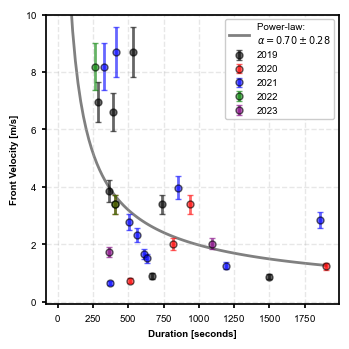

In [196]:
import numpy as np
from scipy.odr import RealData, Model, ODR
import matplotlib.pyplot as plt

def pl(x, A, alpha):
    """Power-law function: A * x^(-alpha)"""
    return A * np.power(x, -alpha)

def linear_function(B, x):
    """ODR-style linear function: B[0]*x + B[1]. Note ODR passes params first."""
    return B[0] * x + B[1]

# --- Uncertainties ---
# y-uncertainty: reuse your existing 10% assumption
sy = np.array(vels) * 0.1
# x-uncertainty: set this to whatever you actually know about duration uncertainty.
# Using a small relative uncertainty as a placeholder — replace with real values if you have them.
sx = np.array(mins) * 0.01

# Guard against zero/negative uncertainties, which ODR can't handle
sy = np.where(sy <= 0, np.nanmin(sy[sy > 0]) if np.any(sy > 0) else 1e-6, sy)
sx = np.where(sx <= 0, np.nanmin(sx[sx > 0]) if np.any(sx > 0) else 1e-6, sx)

mins_arr = np.asarray(mins, dtype=float)
vels_arr = np.asarray(vels, dtype=float)

# sy = sy[mins_arr < 1200]
# sx = sx[mins_arr < 1200]
# vels_arr = vels_arr[mins_arr < 1200]
# mins_arr = mins_arr[mins_arr < 1200]

# ============================================================
# Power-law fit via ODR (fit in log-log space since
# log(y) = log(A) - alpha*log(x) is linear in the logs)
# ============================================================
try:
    log_x = np.log(mins_arr)
    log_y = np.log(vels_arr)
    # propagate relative uncertainty into log-space: d(log x) = dx/x
    log_sx = sx / mins_arr
    log_sy = sy / vels_arr

    data_pl = RealData(log_x, log_y, sx=log_sx, sy=log_sy)
    model_pl = Model(linear_function)
    odr_pl = ODR(data_pl, model_pl, beta0=[-0.5, 0])  # beta0 = [-alpha, log(A)]
    output_pl = odr_pl.run()

    neg_alpha_odr, logA_odr = output_pl.beta
    alpha_odr = -neg_alpha_odr
    A_odr = np.exp(logA_odr)
    alpha_odr_err, logA_odr_err = output_pl.sd_beta
    A_odr_err = A_odr * logA_odr_err  # propagate error through exp()

    print(f"Power-law (ODR): A={A_odr:.4f}±{A_odr_err:.4f}, alpha={alpha_odr:.4f}±{alpha_odr_err:.4f}")
    print(f"  Reason for convergence: {output_pl.stopreason}")
except Exception as e:
    print(f"Failed to fit power-law via ODR: {e}")
    A_odr, alpha_odr = None, None

# ============================================================
# Linear fit via ODR (direct, in linear space)
# ============================================================
# try:
#     data_lin = RealData(mins_arr, vels_arr, sx=sx, sy=sy)
#     model_lin = Model(linear_function)
#     odr_lin = ODR(data_lin, model_lin, beta0=[-1, 15.0])
#     output_lin = odr_lin.run()

#     m_odr, b_odr = output_lin.beta
#     m_odr_err, b_odr_err = output_lin.sd_beta
#     print(f"Linear (ODR): m={m_odr:.4f}±{m_odr_err:.4f}, b={b_odr:.4f}±{b_odr_err:.4f}")
#     print(f"  Reason for convergence: {output_lin.stopreason}")
# except Exception as e:
#     print(f"Failed to fit linear via ODR: {e}")
#     m_odr, b_odr = None, None

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(3.5,3.5))
ax.errorbar(minutes, vel_2019, yerr=[v * 0.1 for v in vel_2019], fmt='o', alpha=0.6, markersize=5, label="2019", color="black", markeredgecolor="k", capsize=2, elinewidth=2)
ax.errorbar(minutes_20, vel_2020, yerr=[v * 0.1 for v in vel_2020], fmt='o', alpha=0.6, markersize=5, label="2020", color="red", markeredgecolor="k", capsize=2, elinewidth=2)
ax.errorbar(minutes_21, vel_2021, yerr=[v * 0.1 for v in vel_2021], fmt='o', alpha=0.6, markersize=5, label="2021", color="blue", markeredgecolor="k", capsize=2, elinewidth=2)
ax.errorbar(minutes_22, vel_2022, yerr=[v * 0.1 for v in vel_2022], fmt='o', alpha=0.6, markersize=5, label="2022", color="green", markeredgecolor="k", capsize=2, elinewidth=2)
ax.errorbar(minutes_23, vel_2023, yerr=[v * 0.1 for v in vel_2023], fmt='o', alpha=0.6, markersize=5, label="2023", color="purple", markeredgecolor="k", capsize=2, elinewidth=2)

x_fit = np.linspace(10, max(mins), 100)

if A_odr is not None:
    y_fit_pl = pl(x_fit, A_odr, alpha_odr)
    ax.plot(x_fit, y_fit_pl, color='grey', linewidth=2, linestyle="-",
            label=f'Power-law: \n$\\alpha={alpha_odr:.2f}\\pm{alpha_odr_err:.2f}$', zorder=0)

# if m_odr is not None:
#     y_fit_lin = linear_function([m_odr, b_odr], x_fit)
#     ax.plot(x_fit, y_fit_lin, color='orange', linewidth=2, linestyle="--",
#             label=f'Linear (ODR): \n$m={m_odr:.3f}\\pm{m_odr_err:.3f}$', zorder=0)

ax.set_ylabel('Front Velocity [m/s]', fontweight='bold', fontsize=7)
ax.set_xlabel('Duration [seconds]', fontweight='bold', fontsize=7)
ax.tick_params(axis='both', which='major', labelsize=7, length=3)
ax.tick_params(axis='y', which='minor', labelsize=7, length=1)
ax.set_ylim(-0.1, 10)
# ax.set_xlim(-50, 1_200)
leg = ax.legend(fontsize=7, loc="best")
if leg:
    leg.get_frame().set_alpha(1)
ax.grid(True, alpha=0.3, linestyle="--")
# fig.gca().spines['top'].set_visible(False)
# fig.gca().spines['right'].set_visible(False)
fig.tight_layout()
# fig.savefig("./output_images27/Velocity-vs-Duration.png", dpi=600, transparent=False)

In [175]:
mins_arr

array([1495.,  395.,  360.,  740.,  530.,  285.,  665.,  405.,  940.,
        815., 1900.,  515.,  855.,  610.,  635.,  370.,  325.,  410.,
       1860.,  505.,  560., 1190.,  405.,  265.,  360., 1095.,  500.])

In [157]:
x = np.array(mins)[:-1]
y = np.array(vels)[:-1]

# if 'popt_mins' in globals():
y_pred = pl(x, *popt_mins)

rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

n = len(y)
k = 1
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)

print(f"Power-law fit metrics:")
print(f"  RMSE       = {rmse:.4f}")
print(f"  MAE        = {mae:.4f}")
print(f"  R^2        = {r2:.4f}")
print(f"  Adj. R^2   = {adj_r2:.4f}")
print(f"  SS_res     = {ss_res:.4f}")
print(f"  SS_tot     = {ss_tot:.4f}")
# else:
#     print("popt_mins is not defined. Run the power-law fitting cell first.")


Power-law fit metrics:
  RMSE       = 2.1371
  MAE        = 1.6574
  R^2        = 0.3284
  Adj. R^2   = 0.3004
  SS_res     = 118.7501
  SS_tot     = 176.8140


In [188]:
def get_starttime_endtime(df):
    # start_idx = df1.index[df1["Timestamps"] == starttime][0]
    col = df1["Predicted_Output_Mean"]
    diffs = col.diff()  # diffs[i] = col[i] - col[i-1]

    starttimes = []
    endtimes = []

    for i in range(len(df1)):
        if diffs.iloc[i] > 0.1:
            starttimes.append(df1["Timestamps"].iloc[i])
        # if diffs.iloc[i] < -0.1: # and diffs.iloc[i + 1] < 0: #and diffs.iloc[i + 2] < 0:
        #     endtimes.append(df1["Timestamps"].iloc[i])
            # break  # keep the break if you only want the first occurrence anyway
    
    # df1["Timestamps"].iloc[diffs[diffs == diffs.min()].index]
    # display(len(starttimes))
    # display(len(endtimes))
    if starttimes:
        starttime = starttimes[0]
    else:
        startime = df1["Timestamps"].iloc[0]
    # if endtimes:
    endtime = df1["Timestamps"].iloc[diffs[diffs == diffs.min()].index].item()
    # else:
        # endtime = df1["Timestamps"].iloc[-1]
    return starttime, endtime

In [174]:
1500 / 60

25.0

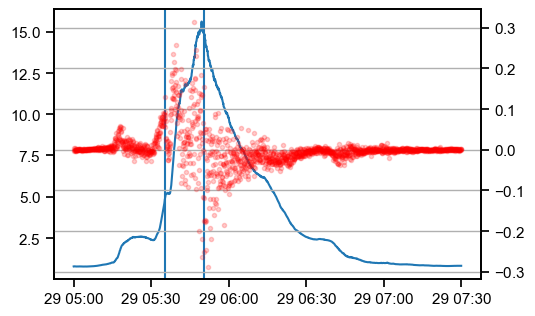

In [198]:
# starttime = df1[df1["Predicted_Output_Mean"] > thr]['Timestamps'].iloc[0]
# endtime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.95)]['Timestamps'].iloc[0]
starttime, endtime = get_starttime_endtime(df1)
# start_idx = df1.index[df1["Timestamps"] == starttime][0]

col = df1["Predicted_Output_Mean"]
diffs = col.diff()  # diffs[i] = col[i] - col[i-1]

# endtimes = []

# for i in range(start_idx + 1, len(df1) - 2):
#     if diffs.iloc[i] < 0 and diffs.iloc[i + 1] < 0 and diffs.iloc[i + 2] < 0:
#         endtimes.append(df1["Timestamps"].iloc[i - 1])
#         break  # keep the break if you only want the first occurrence anyway

# if endtimes:
#     endtime = endtimes[0]
# else:
#     endtime = df1["Timestamps"].iloc[-1]

fig, ax = plt.subplots()
ax.plot(df1.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date), df1.Predicted_Output_Mean)
ax.xaxis_date()
ax.axvline(UTCDateTime(starttime).matplotlib_date)
ax.axvline(UTCDateTime(endtime).matplotlib_date)
# ax.axvline(UTCDateTime("2020-06-17T05:15:45.000000Z").matplotlib_date)

axt = ax.twinx()
axt.plot(df1.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date), diffs, "r.", alpha=0.2)
axt.grid()
# ax.set_xlim(UTCDateTime("2021-05-11T14:30:00"), UTCDateTime("2021-05-11T15:10:00"))

In [185]:
df1["Timestamps"].iloc[diffs[diffs == diffs.min()].index].item()

'2020-06-17T05:15:45.000000Z'

In [183]:
endtime

'2020-06-17T05:00:40.000000Z'

(18758.604166666668, 18758.631944444445)

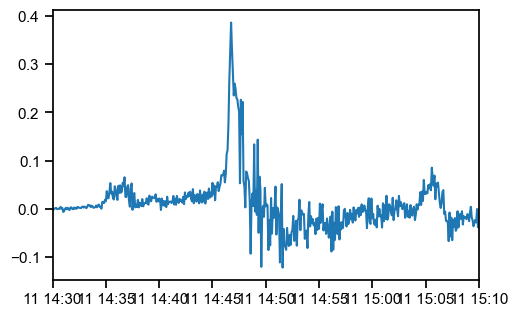

In [92]:
fig, ax = plt.subplots()
ax.plot(df1.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date), diffs)
ax.xaxis_date()
ax.set_xlim(UTCDateTime("2021-05-11T14:30:00"), UTCDateTime("2021-05-11T15:10:00"))

In [88]:
df1.Timestamps

9660     2021-05-11T13:30:00.000000Z
9661     2021-05-11T13:30:05.000000Z
9662     2021-05-11T13:30:10.000000Z
9663     2021-05-11T13:30:15.000000Z
9664     2021-05-11T13:30:20.000000Z
                    ...             
12176    2021-05-11T16:59:40.000000Z
12177    2021-05-11T16:59:45.000000Z
12178    2021-05-11T16:59:50.000000Z
12179    2021-05-11T16:59:55.000000Z
12180    2021-05-11T17:00:00.000000Z
Name: Timestamps, Length: 2521, dtype: object